# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [7]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.
    
    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)
    
    Y_tilde = np.zeros(n)  # outcome residuals
    V_tilde = np.zeros(n)  # treatment residuals (but Bug 2 skips this)
    
    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        
        # BUG 1: Training and predicting on the SAME fold (train_idx)
        # Should train on train_idx, predict on test_idx
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])       # <-- BUG: should be X[test_idx]
        Y_tilde[train_idx] = Y[train_idx] - Y_hat  # <-- BUG: should index test_idx
        
        # BUG 2: Missing treatment residualization entirely
        # Should fit ml_m on D ~ X and compute D_tilde = D - D_hat
        # Instead, just uses raw D as V_tilde
        V_tilde[train_idx] = D[train_idx]  # <-- BUG: should be D[test_idx] - D_hat[test_idx]
    
    # BUG 3: Wrong formula — uses np.mean instead of IV-style ratio
    # Correct: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    theta = np.mean(V_tilde * Y_tilde)  # <-- BUG: wrong formula
    
    return theta


# Run the broken version
broken_ate = broken_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()
print('This estimate is far from the true ATE of 5.0.')
print('Find and fix the 3 bugs to recover the correct estimate.')

=== BROKEN DML Results ===
True ATE:    5.00
Broken ATE:  1.09
Bias:        -3.91

This estimate is far from the true ATE of 5.0.
Find and fix the 3 bugs to recover the correct estimate.


In [9]:
# -----------------------------------------------------------
# YOUR TASK — Fix the broken DML implementation
# After fixing, verify on the simulated DGP (TRUE_ATE = 5.0)
# -----------------------------------------------------------
# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Bug 1 fixed: train on train_idx, predict on test_idx (cross-fitting)
    Bug 2 fixed: residualize D as well as Y
    Bug 3 fixed: use IV-style ratio sum(V*Y_tilde) / sum(V*D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    D_tilde = np.zeros(n)  # treatment residuals

    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # FIX 1: train on train_idx, predict on test_idx (out-of-fold)
        # in-sample prediction overfits and biases residuals toward zero
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[test_idx])       # fixed: predict on test_idx
        Y_tilde[test_idx] = Y[test_idx] - Y_hat  # fixed: index test_idx

        # FIX 2: residualize treatment D on X as well
        # without this, confounding path X -> D is not removed
        # and estimate mixes causal effect with selection bias
        ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        ml_m.fit(X[train_idx], D[train_idx])
        D_hat = ml_m.predict(X[test_idx])
        D_tilde[test_idx] = D[test_idx] - D_hat  # treatment residuals

    # FIX 3: use IV-style ratio instead of np.mean
    # correct formula: theta = sum(D_tilde * Y_tilde) / sum(D_tilde * D)
    # np.mean(V_tilde * Y_tilde) is wrong because it doesn't normalize by
    # the treatment variation, producing a biased and unscaled estimate
    theta = np.sum(D_tilde * Y_tilde) / np.sum(D_tilde * D)

    return theta


# Run the fixed version
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()
print('Fixed estimate should be close to the true ATE of 5.0.')

# VERIFICATION CHECKPOINT
# Your fixed ATE should be within 0.5 of 5.0
# Expected: approximately 4.5 to 5.5
if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.17
Bias:        +0.17

Fixed estimate should be close to the true ATE of 5.0.
PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [12]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------

import pandas as pd
from doubleml import DoubleMLData, DoubleMLPLR
from sklearn.ensemble import RandomForestRegressor

# Set up DoubleMLData
# y_col: 'net_tfa'
# d_cols: 'e401'
# x_cols: everything else

# Load 401(k) data
from doubleml.datasets import fetch_401K
data = fetch_401K(return_type='DataFrame')
# Setup
dml_data = DoubleMLData(
    data,
    y_col='net_tfa',
    d_cols='e401',
    x_cols=['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira', 'hown']
)


# YOUR CODE: Create dml_data, define nuisance learners, fit PLR
# Use RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
# for both ml_l and ml_m. Use n_folds=5.

# YOUR CODE HERE
# Nuisance learners
ml_l = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)
ml_m = RandomForestRegressor(n_estimators=500, max_depth=7, random_state=42)

dml_plr = DoubleMLPLR(dml_data, ml_l, ml_m, n_folds=5)
dml_plr.fit()




# VERIFICATION CHECKPOINT
# Expected ATE: roughly $7,000-$12,000 (depends on random seed and model)
# Expected: statistically significant (p < 0.05)
# print(dml_plr.summary)
# print(f'ATE: ${dml_plr.coef[0]:,.0f}')
# print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}]')
print(dml_plr.summary)
print(f"\nATE: ${dml_plr.coef[0]:,.0f}")
print(f"95% CI: [${dml_plr.confint().iloc[0,0]:,.0f}, ${dml_plr.confint().iloc[0,1]:,.0f}]")

             coef      std err         t         P>|t|        2.5 %  \
e401  8755.227901  1378.646884  6.350595  2.144838e-10  6053.129661   

            97.5 %  
e401  11457.326142  

ATE: $8,755
95% CI: [$6,053, $11,457]


In [13]:
# -----------------------------------------------------------
# YOUR TASK — Run sensitivity analysis
# -----------------------------------------------------------

# Use dml_plr.sensitivity_analysis() to assess robustness
# Parameters:
#   cf_y = 0.03  (bound on confounding strength for outcome)
#   cf_d = 0.03  (bound on confounding strength for treatment)
#
# After running:
# 1. Print dml_plr.sensitivity_summary
# 2. Interpret the robustness value
#    - If robustness_value > 1: estimate is very robust
#    - If robustness_value < 1: an omitted variable of moderate
#      strength could flip the sign

# YOUR CODE HERE

dml_plr.sensitivity_analysis()
print(dml_plr.sensitivity_summary)


# VERIFICATION CHECKPOINT
# The robustness value should be positive.
# A value > 0 means the estimate survives some degree of confounding.

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower        theta   theta upper     CI upper
e401  2654.685425  4984.416387  8755.227901  12526.039415  14814.82334

------------------ Robustness Values ------------------
      H_0    RV (%)  RVa (%)
e401  0.0  6.826757  4.99069


---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [14]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col]]

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915, 1)
X shape: (9915, 12)
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


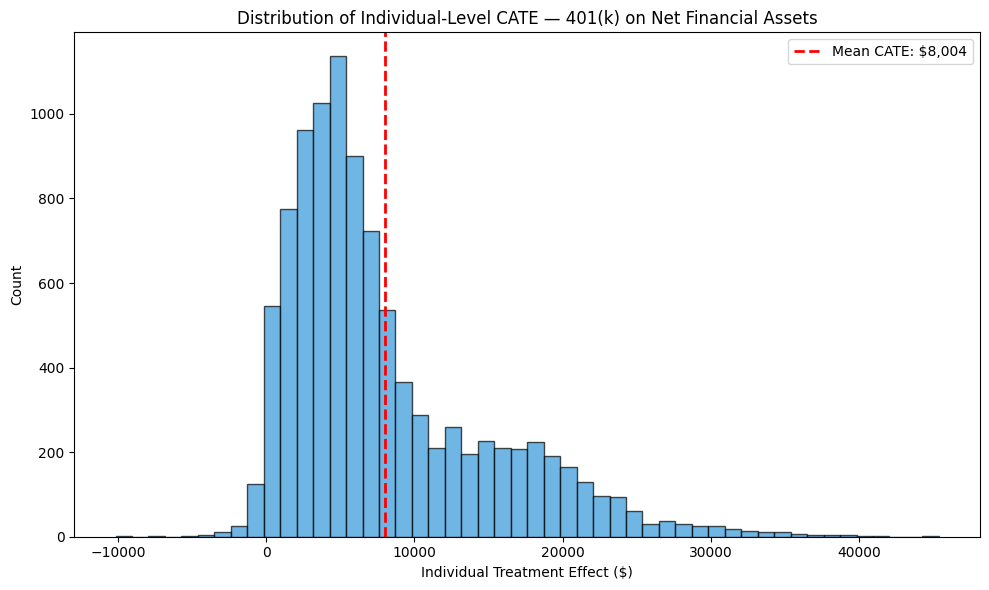

Mean CATE: $8,004
Median CATE: $5,779
Std CATE: $6,870
Range: $-10,152 to $45,365
       High CATE (Top 25%)  Low CATE (Bottom 25%)  Full Sample
age                  44.19                  35.36        41.06
inc               67374.66               20308.34     37200.62
educ                 14.21                  12.24        13.21
fsize                 3.03                   2.74         2.87
marr                  0.82                   0.49         0.60
pira                  0.47                   0.13         0.24


In [17]:
# -----------------------------------------------------------
# YOUR TASK — Fit Causal Forest and extract CATE predictions
# -----------------------------------------------------------

# Step 1: Fit the Causal Forest
# Hint: cf.fit(Y, D, X=X)
# This may take 1-3 minutes.

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt


# YOUR CODE HERE

# Prepare data
Y = data['net_tfa'].values
D = data['e401'].values
X = data[['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira', 'hown']].values

# Fit Causal Forest
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42),
    n_estimators=1000,
    min_samples_leaf=20,
    random_state=42,
    cv=5
)
cf.fit(Y, D, X=X)
cf.fit(Y, D, X=X)
cate_pred = cf.effect(X)


# CATE histogram
plt.figure(figsize=(10, 6))
plt.hist(cate_pred, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
plt.axvline(x=np.mean(cate_pred), color='red', linestyle='--', linewidth=2,
            label=f'Mean CATE: ${np.mean(cate_pred):,.0f}')
plt.xlabel('Individual Treatment Effect ($)')
plt.ylabel('Count')
plt.title('Distribution of Individual-Level CATE — 401(k) on Net Financial Assets')
plt.legend()
plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/cate_histogram.png', dpi=150)
plt.show()

print(f"Mean CATE: ${np.mean(cate_pred):,.0f}")
print(f"Median CATE: ${np.median(cate_pred):,.0f}")
print(f"Std CATE: ${np.std(cate_pred):,.0f}")
print(f"Range: ${np.min(cate_pred):,.0f} to ${np.max(cate_pred):,.0f}")


# Step 2: Extract individual CATE predictions
# Hint: cate_predictions = cf.effect(X)
# This returns one treatment effect estimate per observation.

# YOUR CODE HERE
data['cate'] = cate_pred


# Step 3: Get confidence intervals
# Hint: cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)

# YOUR CODE HERE
# Top 25% of Responders 
threshold = np.percentile(cate_pred, 75)
high_responders = data[data['cate'] >= threshold]
low_responders = data[data['cate'] < np.percentile(cate_pred, 25)]

# Compare characteristics
comparison = pd.DataFrame({
    'High CATE (Top 25%)': high_responders[['age', 'inc', 'educ', 'fsize', 'marr', 'pira']].mean(),
    'Low CATE (Bottom 25%)': low_responders[['age', 'inc', 'educ', 'fsize', 'marr', 'pira']].mean(),
    'Full Sample': data[['age', 'inc', 'educ', 'fsize', 'marr', 'pira']].mean()
})
print(comparison.round(2))


# VERIFICATION CHECKPOINT
# Expected: cate_predictions.shape should be (n,) where n = len(data)
# Expected: mean CATE should be roughly similar to the DML ATE
# print(f'CATE predictions shape: {cate_predictions.shape}')
# print(f'Mean CATE:  ${np.mean(cate_predictions):,.0f}')
# print(f'Std CATE:   ${np.std(cate_predictions):,.0f}')
# print(f'Min CATE:   ${np.min(cate_predictions):,.0f}')
# print(f'Max CATE:   ${np.max(cate_predictions):,.0f}')

In [18]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot a histogram of individual CATE estimates
# Include a vertical line at the mean CATE and the DML ATE for comparison

# YOUR CODE HERE


# Step 2: Identify the "high-response" subgroup
# Define high-response as individuals with CATE above the 75th percentile
# Compare their characteristics to the rest of the sample

# Hint:
# threshold = np.percentile(cate_predictions, 75)
# high_resp = data[cate_predictions >= threshold]
# low_resp = data[cate_predictions < threshold]
# Compare mean income, age, education, etc.

# YOUR CODE HERE
# src/causal_ml.py
"""Causal ML module for DML and CATE analysis."""

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import KFold
from typing import Tuple, Optional


def manual_dml(
    Y: np.ndarray,
    D: np.ndarray,
    X: np.ndarray,
    ml_l,
    ml_m,
    n_folds: int = 5,
    random_state: int = 42
) -> Tuple[float, float]:
    """
    Manual Double ML with cross-fitting.
    
    Returns: (theta, se)
    """
    n = len(Y)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    Y_hat = np.zeros(n)
    D_hat = np.zeros(n)
    
    for train_idx, test_idx in kf.split(X):
        # Outcome model
        ml_l_k = clone(ml_l)
        ml_l_k.fit(X[train_idx], Y[train_idx])
        Y_hat[test_idx] = ml_l_k.predict(X[test_idx])
        
        # Treatment model
        ml_m_k = clone(ml_m)
        ml_m_k.fit(X[train_idx], D[train_idx])
        D_hat[test_idx] = ml_m_k.predict(X[test_idx])
    
    V_hat = Y - Y_hat
    W_hat = D - D_hat
    
    theta = np.sum(W_hat * V_hat) / np.sum(W_hat * W_hat)
    residuals = V_hat - theta * W_hat
    se = np.sqrt(np.sum(W_hat**2 * residuals**2) / (np.sum(W_hat**2))**2)
    
    return theta, se


def cate_by_subgroup(
    data: pd.DataFrame,
    y_col: str,
    d_col: str,
    x_cols: list,
    group_col: str,
    ml_l,
    ml_m,
    n_folds: int = 5
) -> pd.DataFrame:
    """Estimate CATE for each subgroup."""
    from doubleml import DoubleMLData, DoubleMLPLR
    
    results = []
    for group_val in sorted(data[group_col].unique()):
        subset = data[data[group_col] == group_val]
        dml_data = DoubleMLData(subset, y_col=y_col, d_cols=d_col, x_cols=x_cols)
        dml = DoubleMLPLR(dml_data, clone(ml_l), clone(ml_m), n_folds=n_folds)
        dml.fit()
        ci = dml.confint()
        results.append({
            'group': group_val,
            'n': len(subset),
            'ate': dml.coef[0],
            'se': dml.se[0],
            'ci_lower': ci.iloc[0, 0],
            'ci_upper': ci.iloc[0, 1]
        })
    
    return pd.DataFrame(results)

# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).
# If all subgroup means are identical, something went wrong.

---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

*Your answer:*

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.